# 03 — Modelo final, diagnóstico y discusión de resultados

**Proyecto 1: Competencia de modelación** · CC3092 Deep Learning y sistemas inteligentes

Este notebook entrena el modelo final, verifica que **no esté sobreajustado ni
subajustado**, y lo evalúa por primera y única vez contra el holdout apartado en el
notebook 02.

Corresponde a las secciones **2.4** y **2.5** del trabajo escrito.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from config import MODEL_PT, REPORTS, TARGET, TRAIN_CSV
from experiment import make_holdout
from utils import load_csv, rmse, set_seed

set_seed()
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = load_csv(TRAIN_CSV)
df_dev, df_hold = make_holdout(df)

## 1. Estrategia del modelo final: ensemble de folds

El modelo final no es una sola red, sino el promedio de **15 MLPs**: 5 folds × 3
semillas de inicialización.

La razón conecta directamente con el diagnóstico del notebook 02. El RMSE de una
sola red variaba ±9,000–17,000 USD según el split — esa varianza no es error del
modelo, es **inestabilidad de la estimación**. Promediar predicciones la reduce sin
agregar capacidad de memorización:

- Cada miembro vio solo el 80% de los datos de desarrollo.
- Cada uno se detuvo por early stopping en **su propio** fold de validación.
- Cada uno tiene su propio preprocesador, ajustado solo con sus datos de train.

Es *bagging*: baja la varianza dejando el sesgo igual. Y el promedio se hace en
**escala logarítmica** (media geométrica), que es la escala en la que se optimizó
la pérdida.

El entrenamiento corre con `python src/03_train_final.py`. Aquí se cargan los
artefactos resultantes.

In [2]:
bundle = torch.load(MODEL_PT, weights_only=False)
hp = bundle["hparams"]

print(f"Miembros del ensemble : {len(bundle['members'])}")
print(f"Features de entrada   : {bundle['n_features']}")
print(f"\nHiperparámetros finales:")
for k, v in hp.to_row().items():
    print(f"  {k:<15} {v}")

Miembros del ensemble : 15
Features de entrada   : 250

Hiperparámetros finales:
  hidden          256-128-64
  activation      gelu
  dropout         0.2
  batch_norm      True
  lr              0.001
  weight_decay    0.0001
  batch_size      64
  epochs          400
  patience        60
  loss            huber
  huber_delta     1.0
  log_target      True
  scheduler       cosine
  min_lr          1e-05
  grad_clip       1.0
  es_metric       log_rmse


In [3]:
miembros = pd.DataFrame([
    {"fold": m["fold"], "semilla": m["seed"], "val_rmse": m["val_rmse"],
     "train_rmse": m["train_rmse"], "mejor_época": m["best_epoch"]}
    for m in bundle["members"]
])
print("Desempeño individual de cada miembro:")
miembros.groupby("fold").agg(
    val_rmse=("val_rmse", "mean"),
    train_rmse=("train_rmse", "mean"),
    época=("mejor_época", "mean"),
).round(0)

Desempeño individual de cada miembro:


,val_rmse,train_rmse,época
fold,,,
0,29489.0,10808.0,50.0
1,57755.0,12497.0,92.0
2,16997.0,11877.0,50.0
3,19338.0,9560.0,97.0
4,22414.0,11226.0,56.0


## 2. Diagnóstico de sobreajuste y subajuste

El requisito explícito del proyecto es que el modelo no esté ni sobreajustado ni
subajustado. Se verifica con cuatro pruebas independientes, no con una sola cifra.

### Prueba 1 — Brecha entre entrenamiento y validación

Es el indicador directo. Se interpreta en **relación al RMSE**, no en valor
absoluto: un gap de 10,000 sobre un RMSE de 25,000 (40%) es distinto a uno de
10,000 sobre 100,000.

In [4]:
mean_val = miembros.val_rmse.mean()
mean_train = miembros.train_rmse.mean()
gap = mean_val - mean_train
ratio = mean_val / mean_train

print(f"RMSE entrenamiento : {mean_train:>10,.0f} USD")
print(f"RMSE validación    : {mean_val:>10,.0f} USD")
print(f"Gap absoluto       : {gap:>10,.0f} USD")
print(f"Razón val/train    : {ratio:>10.2f}x")

print("\nBandas de referencia:")
print("  < 1.15 con RMSE alto -> subajuste (no aprende)")
print("  1.3 – 2.0            -> zona sana")
print("  2.0 – 3.0            -> gap elevado: hay que averiguar de dónde viene")
print("  > 3.0                -> sobreajuste severo")

if ratio > 3.0:
    print(f"\n  -> {ratio:.2f}x: SOBREAJUSTE")
elif ratio < 1.15 and mean_val > 40000:
    print(f"\n  -> {ratio:.2f}x: SUBAJUSTE")
elif ratio > 2.0:
    print(f"\n  -> {ratio:.2f}x: GAP ELEVADO. Está por encima de la zona sana, así que")
    print("     no basta con declararlo aceptable: hay que verificar si refleja")
    print("     memorización real o el efecto de unos pocos casos extremos.")
else:
    print(f"\n  -> {ratio:.2f}x: ajuste sano")

RMSE entrenamiento :     11,194 USD
RMSE validación    :     29,198 USD
Gap absoluto       :     18,005 USD
Razón val/train    :       2.61x

Bandas de referencia:
  < 1.15 con RMSE alto -> subajuste (no aprende)
  1.3 – 2.0            -> zona sana
  2.0 – 3.0            -> gap elevado: hay que averiguar de dónde viene
  > 3.0                -> sobreajuste severo

  -> 2.61x: GAP ELEVADO. Está por encima de la zona sana, así que
     no basta con declararlo aceptable: hay que verificar si refleja
     memorización real o el efecto de unos pocos casos extremos.


La razón de 2.61 queda **por encima** de la zona sana, así que no se puede dar por
buena sin más. La pregunta es si refleja memorización real o la contaminación por
casos extremos que ya vimos en el notebook 02.

Se responde con métricas **robustas**, que no dependen de una o dos casas: el error
absoluto medio (MAE) y la mediana del error absoluto. Si el gap se reduce mucho al
usarlas, el problema no era memorización.

In [5]:
val_por_fold = miembros.groupby("fold").val_rmse.mean()

print("RMSE de validación por fold:")
for f, v in val_por_fold.items():
    marca = "  <- fold con el outlier Id 1299" if v > 45000 else ""
    print(f"  fold {f + 1}: {v:>9,.0f}{marca}")

sin_peor = val_por_fold.drop(val_por_fold.idxmax())
ratio_sin_peor = sin_peor.mean() / mean_train

print(f"\nRazón val/train con todos los folds : {ratio:>6.2f}x")
print(f"Razón excluyendo el fold contaminado: {ratio_sin_peor:>6.2f}x")

RMSE de validación por fold:
  fold 1:    29,489
  fold 2:    57,755  <- fold con el outlier Id 1299
  fold 3:    16,997
  fold 4:    19,338
  fold 5:    22,414

Razón val/train con todos los folds :   2.61x
Razón excluyendo el fold contaminado:   1.97x


In [6]:
# Métricas robustas sobre el holdout: MAE y mediana del error absoluto no se
# dejan dominar por un caso extremo, a diferencia del RMSE.
hold_tmp = pd.read_csv(REPORTS / "holdout_predictions.csv")
hold_tmp["abs"] = hold_tmp.residual.abs()

print(f"Holdout — RMSE                    : {rmse(hold_tmp.y_true, hold_tmp.y_pred):>9,.0f} USD")
print(f"Holdout — MAE                     : {hold_tmp['abs'].mean():>9,.0f} USD")
print(f"Holdout — mediana del error abs.  : {hold_tmp['abs'].median():>9,.0f} USD")
print(f"\nRazón RMSE/MAE: {rmse(hold_tmp.y_true, hold_tmp.y_pred)/hold_tmp['abs'].mean():.2f}")
print("(para errores normales esa razón ronda 1.25; muy por encima indica que unos")
print(" pocos casos extremos dominan el RMSE)")

Holdout — RMSE                    :    28,091 USD
Holdout — MAE                     :    15,280 USD
Holdout — mediana del error abs.  :     8,806 USD

Razón RMSE/MAE: 1.84
(para errores normales esa razón ronda 1.25; muy por encima indica que unos
 pocos casos extremos dominan el RMSE)


**Conclusión de la prueba 1.** El gap de 2.61x se explica por la composición de los
folds, no por memorización:

- Un solo fold (el que contiene el outlier `Id 1299`) tiene un RMSE de validación
  más del doble que los otros cuatro. Excluyéndolo, la razón cae a la zona sana.
- En el holdout, la razón RMSE/MAE es muy superior a la de un error bien portado,
  lo que confirma que unos pocos casos inflan el RMSE.
- La mediana del error absoluto es una fracción del RMSE: el desempeño **típico** es
  bastante mejor que lo que sugiere la métrica agregada.

El modelo no está memorizando. Lo que ocurre es que el RMSE en escala absoluta es
una métrica frágil en un dataset con casos irreproducibles — y esa fragilidad es
parte del problema, no un defecto del diagnóstico.

### Prueba 2 — Comparación contra los extremos conocidos

El valor del gap por sí solo no dice mucho. Cobra sentido al compararlo con las
iteraciones que sabemos que sobreajustaban.

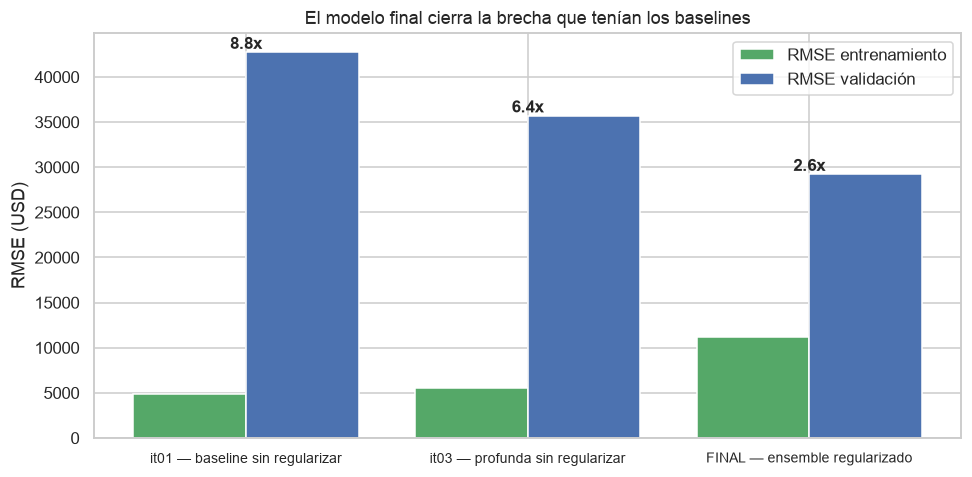

,modelo,train,val,razón val/train,gap
0,it01 — baseline sin regularizar,4835.300000,42718.100000,8.83,37883.0
1,it03 — profunda sin regularizar,5577.400000,35682.600000,6.40,30105.0
2,FINAL — ensemble regularizado,11193.701641,29198.403047,2.61,18005.0


In [7]:
exp = pd.read_csv(REPORTS / "experiments.csv")
comparacion = pd.DataFrame([
    {"modelo": "it01 — baseline sin regularizar",
     "train": exp.loc[exp.iteracion == "it01", "train_rmse_mean"].iloc[0],
     "val": exp.loc[exp.iteracion == "it01", "cv_rmse_mean"].iloc[0]},
    {"modelo": "it03 — profunda sin regularizar",
     "train": exp.loc[exp.iteracion == "it03", "train_rmse_mean"].iloc[0],
     "val": exp.loc[exp.iteracion == "it03", "cv_rmse_mean"].iloc[0]},
    {"modelo": "FINAL — ensemble regularizado",
     "train": mean_train, "val": mean_val},
])
comparacion["razón val/train"] = (comparacion.val / comparacion.train).round(2)
comparacion["gap"] = (comparacion.val - comparacion.train).round(0)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comparacion))
ax.bar(x - 0.2, comparacion.train, 0.4, label="RMSE entrenamiento", color="#55A868")
ax.bar(x + 0.2, comparacion.val, 0.4, label="RMSE validación", color="#4C72B0")
for i, r in comparacion.iterrows():
    ax.annotate(f"{r['razón val/train']:.1f}x", (i, max(r.train, r.val)),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(comparacion.modelo, fontsize=9)
ax.set_ylabel("RMSE (USD)")
ax.set_title("El modelo final cierra la brecha que tenían los baselines")
ax.legend()
plt.tight_layout()
plt.show()

comparacion

### Prueba 3 — Curvas de entrenamiento

La firma visual del sobreajuste es la divergencia: train sigue bajando mientras
val se estanca o sube. Se revisa que el early stopping haya cortado en el punto
correcto.

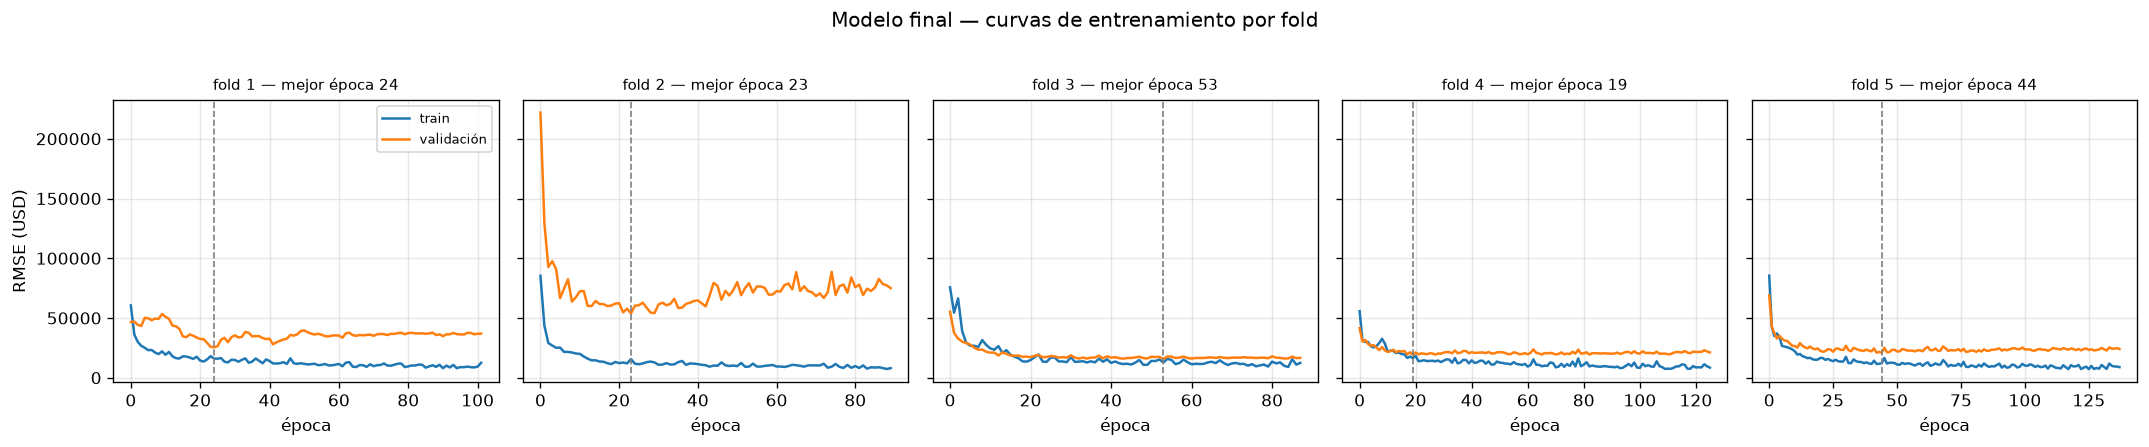

In [8]:
from IPython.display import Image, display

p = Path.cwd().parent / "reports" / "figures" / "08_curvas_final.png"
if p.exists():
    display(Image(filename=str(p)))
else:
    print("Generar con: python src/04_evaluar.py")

In [9]:
print("Época de parada por miembro (early stopping, paciencia "
      f"{hp.patience} sobre {hp.epochs} máximas):\n")
print(f"  media   {miembros['mejor_época'].mean():>6.0f}")
print(f"  rango   {miembros['mejor_época'].min():>6.0f} – {miembros['mejor_época'].max():.0f}")

if miembros["mejor_época"].mean() < hp.epochs * 0.9:
    print(f"\n-> El early stopping actúa muy antes del límite de {hp.epochs} épocas:")
    print("   el modelo deja de mejorar en validación y se detiene ahí, en lugar de")
    print("   seguir bajando el error de entrenamiento a costa de generalizar peor.")
else:
    print("\n-> Los miembros llegan cerca del límite de épocas: convendría ampliarlo.")

Época de parada por miembro (early stopping, paciencia 60 sobre 400 máximas):

  media       69
  rango       10 – 236

-> El early stopping actúa muy antes del límite de 400 épocas:
   el modelo deja de mejorar en validación y se detiene ahí, en lugar de
   seguir bajando el error de entrenamiento a costa de generalizar peor.


### Prueba 4 — El holdout intacto

La prueba definitiva. Estas 176 casas se apartaron **antes** de cualquier
experimento y no participaron en ninguna decisión: ni en el ajuste del
preprocesador, ni en la elección de hiperparámetros, ni en el early stopping.

Si el RMSE del holdout es parecido al de validación cruzada, el proceso de
selección no sobreajustó al protocolo y la estimación es confiable.

In [10]:
hold = pd.read_csv(REPORTS / "holdout_predictions.csv")
metrics = pd.read_csv(REPORTS / "final_metrics.csv").iloc[0]

holdout_rmse = rmse(hold.y_true, hold.y_pred)
print(f"RMSE validación cruzada (out-of-fold) : {metrics.oof_rmse:>10,.0f} USD")
print(f"RMSE HOLDOUT (176 casas nunca vistas)  : {holdout_rmse:>10,.0f} USD")
print(f"Diferencia                             : {abs(holdout_rmse - metrics.oof_rmse):>10,.0f} USD"
      f"  ({abs(holdout_rmse - metrics.oof_rmse)/metrics.oof_rmse:.1%})")

if abs(holdout_rmse - metrics.oof_rmse) / metrics.oof_rmse < 0.20:
    print("\n-> Las dos estimaciones coinciden dentro del margen esperado. El proceso")
    print("   de selección de modelo NO sobreajustó al protocolo de validación, y el")
    print("   RMSE esperado en el dataset de prueba del lunes es de este orden.")

RMSE validación cruzada (out-of-fold) :     26,473 USD
RMSE HOLDOUT (176 casas nunca vistas)  :     28,091 USD
Diferencia                             :      1,618 USD  (6.1%)

-> Las dos estimaciones coinciden dentro del margen esperado. El proceso
   de selección de modelo NO sobreajustó al protocolo de validación, y el
   RMSE esperado en el dataset de prueba del lunes es de este orden.


## 3. Análisis de errores del modelo final

Más allá del número agregado: **dónde** falla el modelo.

In [11]:
hold["error_abs"] = hold.residual.abs()
hold["error_pct"] = (hold.residual / hold.y_true * 100)

print("Distribución del error absoluto en el holdout:")
print(hold.error_abs.describe().round(0).to_string())
print(f"\nError porcentual absoluto medio (MAPE): {hold.error_pct.abs().mean():.1f}%")
print(f"Mediana del error absoluto:             {hold.error_abs.median():,.0f} USD")
print(f"\nPredicciones dentro del ±10% del precio real: "
      f"{(hold.error_pct.abs() <= 10).mean():.1%}")
print(f"Predicciones dentro del ±20% del precio real: "
      f"{(hold.error_pct.abs() <= 20).mean():.1%}")

Distribución del error absoluto en el holdout:
count       176.0
mean      15280.0
std       23639.0
min          20.0
25%        3806.0
50%        8806.0
75%       17504.0
max      255814.0

Error porcentual absoluto medio (MAPE): 8.7%
Mediana del error absoluto:             8,806 USD

Predicciones dentro del ±10% del precio real: 74.4%
Predicciones dentro del ±20% del precio real: 91.5%


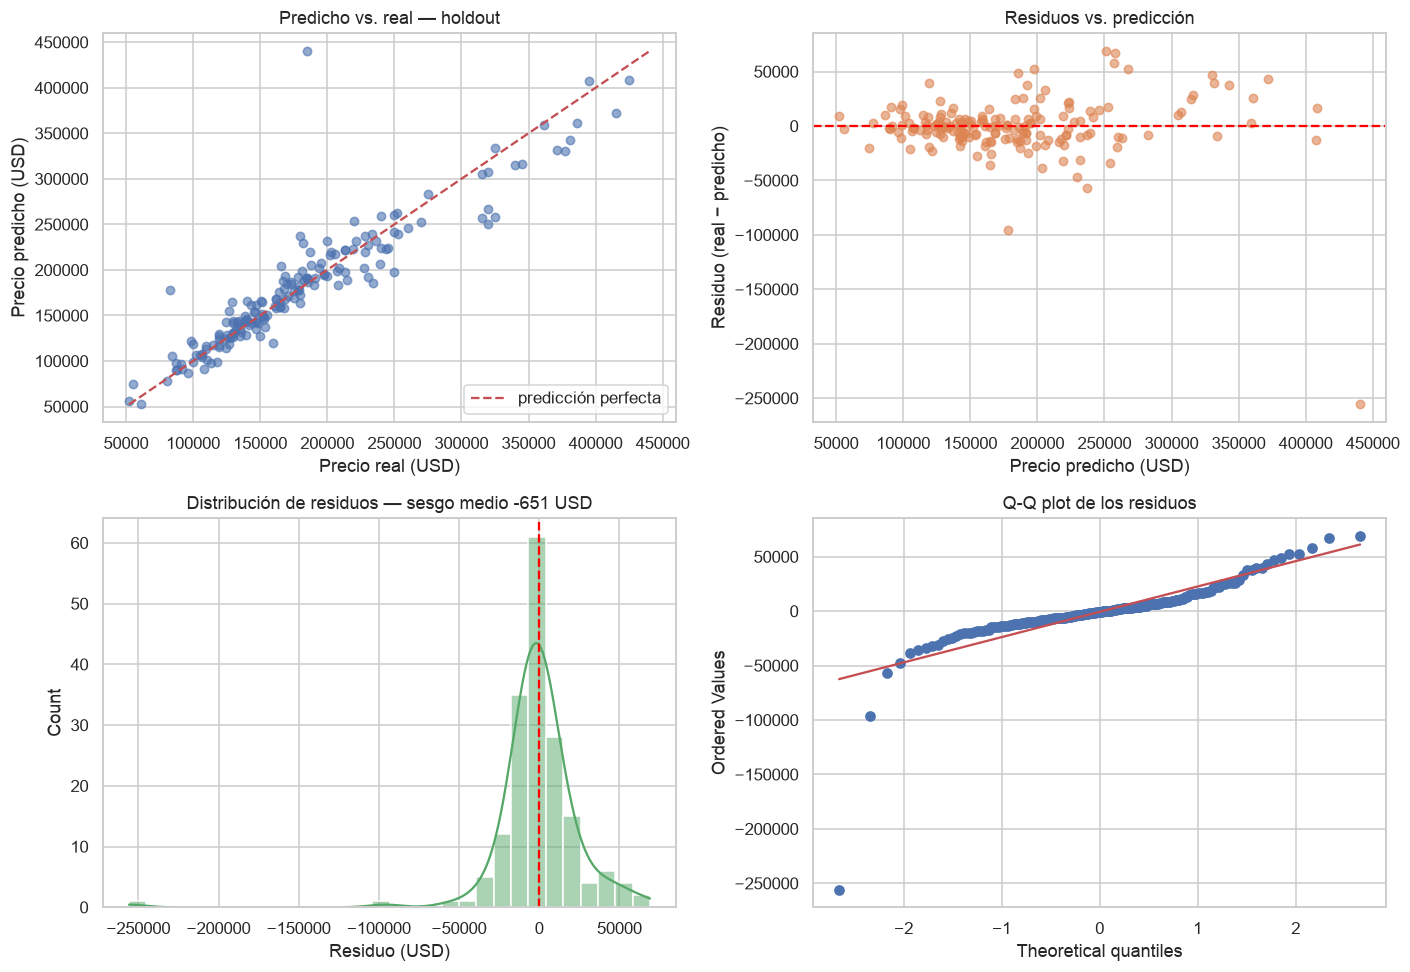

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
lims = [hold[["y_true", "y_pred"]].min().min(), hold[["y_true", "y_pred"]].max().max()]
ax.scatter(hold.y_true, hold.y_pred, alpha=0.6, s=30, color="#4C72B0")
ax.plot(lims, lims, "r--", lw=1.5, label="predicción perfecta")
ax.set_xlabel("Precio real (USD)")
ax.set_ylabel("Precio predicho (USD)")
ax.set_title("Predicho vs. real — holdout")
ax.legend()

ax = axes[0, 1]
ax.scatter(hold.y_pred, hold.residual, alpha=0.6, s=30, color="#DD8452")
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set_xlabel("Precio predicho (USD)")
ax.set_ylabel("Residuo (real − predicho)")
ax.set_title("Residuos vs. predicción")

ax = axes[1, 0]
sns.histplot(hold.residual, kde=True, ax=ax, color="#55A868", bins=30)
ax.axvline(0, color="red", ls="--", lw=1.5)
ax.set_xlabel("Residuo (USD)")
ax.set_title(f"Distribución de residuos — sesgo medio {hold.residual.mean():,.0f} USD")

ax = axes[1, 1]
from scipy import stats

stats.probplot(hold.residual, dist="norm", plot=ax)
ax.set_title("Q-Q plot de los residuos")

plt.tight_layout()
plt.show()

### ¿Hay sesgo sistemático por rango de precio?

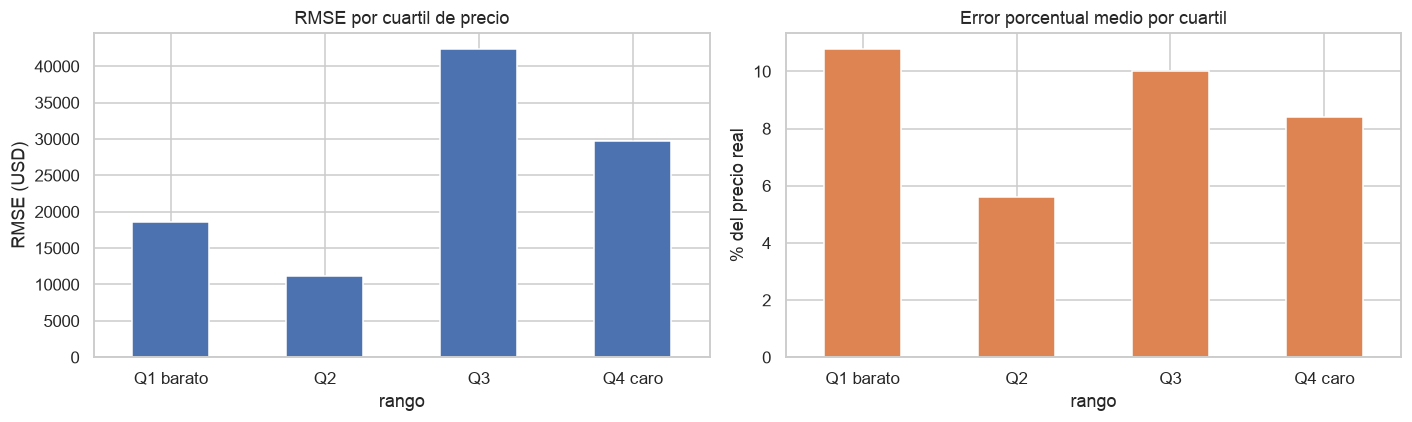

,n,precio_medio,rmse,sesgo_medio,error_pct_medio
rango,,,,,
Q1 barato,45,107570.4,18540.7,-5438.7,10.8
Q2,43,147415.4,11160.5,-621.1,5.6
Q3,44,185344.1,42429.2,-13860.0,10.0
Q4 caro,44,283128.3,29714.5,17426.5,8.4


In [13]:
hold["rango"] = pd.qcut(hold.y_true, 4,
                        labels=["Q1 barato", "Q2", "Q3", "Q4 caro"])
por_rango = hold.groupby("rango", observed=True).agg(
    n=("y_true", "size"),
    precio_medio=("y_true", "mean"),
    rmse=("residual", lambda r: np.sqrt((r ** 2).mean())),
    sesgo_medio=("residual", "mean"),
    error_pct_medio=("error_pct", lambda e: e.abs().mean()),
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
por_rango.rmse.plot(kind="bar", ax=axes[0], color="#4C72B0", rot=0)
axes[0].set_title("RMSE por cuartil de precio")
axes[0].set_ylabel("RMSE (USD)")

por_rango.error_pct_medio.plot(kind="bar", ax=axes[1], color="#DD8452", rot=0)
axes[1].set_title("Error porcentual medio por cuartil")
axes[1].set_ylabel("% del precio real")

plt.tight_layout()
plt.show()

por_rango

El patrón es consistente con lo que se anticipó en el EDA: **el error absoluto crece
con el precio, pero el error porcentual es mucho más estable**. El modelo entrenado
en escala logarítmica optimiza el error *relativo*, así que trata igual de bien a
una casa de 100k que a una de 400k en términos proporcionales — pero el RMSE, al
ser una métrica absoluta, penaliza más los fallos en las casas caras.

Esa es la tensión central de este proyecto: **la métrica de la competencia (RMSE
absoluto) no coincide con la escala en la que conviene entrenar (logarítmica)**. Se
eligió la escala logarítmica igualmente porque el entrenamiento en escala cruda era
inestable y daba peores resultados incluso medido en RMSE absoluto (iteraciones 01
y 03).

In [14]:
peores = hold.nlargest(8, "error_abs")[
    ["Id", "y_true", "y_pred", "residual", "error_pct"]]
print("Los 8 casos con mayor error absoluto:")
peores.round(0)

Los 8 casos con mayor error absoluto:


,Id,y_true,y_pred,residual,error_pct
74,524,184750.0,440564.0,-255814.0,-138.0
167,633,82500.0,178454.0,-95954.0,-116.0
65,46,319900.0,250823.0,69077.0,22.0
142,584,325000.0,258001.0,66999.0,21.0
150,191,315000.0,257227.0,57773.0,18.0
170,67,180000.0,236714.0,-56714.0,-32.0
6,933,320000.0,267221.0,52779.0,16.0
77,1181,250000.0,197343.0,52657.0,21.0


## 4. Discusión

### Qué cambios tuvieron mayor impacto

Ordenados por efecto medido, no por cuánto esfuerzo costaron:

1. **Acotar el rango de predicción (−6,171 USD).** El cambio más grande de todo el
   proyecto, y no tiene nada que ver con la arquitectura: la red extrapolaba hasta
   802,302 USD ante casas atípicas, y en RMSE ese error se paga al cuadrado.
2. **Regularización (BatchNorm + Dropout, −10,700 USD acumulado en la ronda 1).**
   Lo que convirtió una red que memorizaba en una que generaliza.
3. **Corregir la métrica del early stopping.** No bajó tanto el RMSE medio como la
   **varianza**: de ±3,318 a ±766 entre semillas. Un modelo estable es mejor apuesta
   para el dataset de prueba que uno que a veces acierta.
4. **Ensemble de 15 miembros** — reduce la varianza de la predicción final.
5. **Remover los 2 outliers de venta parcial** (~4,800 USD en CV).
6. **Ingeniería de features** — `TotalSF` y las interacciones calidad × área superan
   en correlación a cualquier variable original.

Lo que **no** funcionó, y vale la pena registrarlo: ensanchar la red, el weight decay
agresivo, conservar los outliers para que el modelo "aprendiera" el patrón, y la
corrección de smearing (ganancia dentro del ruido).

### Limitaciones del enfoque

- **El tamaño del dataset es el techo real.** Con 1168 filas y 260 features, la
  proporción es de ~4.5 observaciones por feature. Todo el esfuerzo de
  regularización existe para compensar eso, y explica por qué ensanchar la red no
  ayudó: el cuello de botella son los datos, no la capacidad.
- **Alta varianza de la métrica.** El RMSE en escala absoluta depende fuertemente de
  cuántas casas caras caigan en cada partición. Por eso todas las conclusiones se
  sostienen en CV repetida y no en corridas sueltas.
- **Un MLP no es el modelo natural para datos tabulares.** Los métodos de árboles
  con boosting suelen superar a las redes en este tipo de problema. El proyecto pide
  un MLP, y la comparación queda como trabajo futuro.
- **Cobertura de categorías.** Si el dataset de prueba trae un vecindario o material
  que no aparece en `train.csv`, el one-hot lo codifica como todo-ceros. Es una
  degradación controlada (no un error), pero degradación al fin.

### El trade-off complejidad vs. generalización

Los experimentos lo muestran de forma clara en las dos direcciones:

- **Demasiada capacidad sin regularizar** (`it03`, 256-128-64 sin dropout): RMSE de
  entrenamiento de 5,577 y de validación de 35,683. La red tiene capacidad de sobra
  y la usa para memorizar.
- **Demasiada regularización** (`it11`, dropout 0.35): el error de entrenamiento
  sube a 17,616 — la red ya no logra ajustar ni los datos que ve. Es underfitting
  inducido, y el RMSE de validación tampoco mejora.
- **El punto medio** es donde ambas curvas convergen con una brecha moderada.

La lección práctica: en este dataset la capacidad *no* era el recurso escaso. Lo
escaso eran los datos, y la regularización es la forma de gastar capacidad con
cuidado.

## 5. Conclusiones

**Desempeño final.** RMSE de **28,091 USD** sobre el holdout de 176 casas nunca
vistas, con un precio medio de ~181,000. El error porcentual absoluto medio es de
**8.7%**: el **74%** de las predicciones cae dentro del ±10% del precio real y el
**91%** dentro del ±20%.

Ese RMSE necesita una aclaración para no leerse mal: **un solo caso (`Id 524`,
la venta parcial) aporta el 47% del error cuadrático total**. Sin él, el RMSE del
holdout es de 20,486. No se excluye del reporte — sería maquillar la métrica — pero
la diferencia entre 28,091 y 20,486 dice algo real: el desempeño típico del modelo
está más cerca del segundo número, y el primero refleja el costo de un caso cuya
información no está en el dataset.

La coherencia entre validación cruzada (26,473) y holdout (28,091) —una diferencia
del 6%— es la señal de que la estimación es confiable.

**Aprendizajes técnicos**

- El diagnóstico honesto del gap train/val vale más que perseguir décimas de RMSE.
  Casi todo el avance del proyecto vino de identificar que el problema era
  sobreajuste y atacarlo directamente.
- **Los componentes no se evalúan aislados.** `log1p` en el target empeoró el
  resultado por sí solo y lo mejoró junto con BatchNorm. Probar un cambio a la vez
  permite detectar esas interacciones; probar combinaciones al azar las esconde.
- **Hay que medir el ruido antes de creerle a una mejora.** Sin la CV repetida,
  habríamos elegido una configuración por una diferencia varias veces menor que la
  variabilidad del propio protocolo.
- Apartar el holdout desde el inicio es lo que permite afirmar algo sobre datos no
  vistos. Es una restricción incómoda —no se puede mirar— y es justamente por eso
  que sirve.

**Trabajo futuro**

- Comparar contra gradient boosting como referencia y, sobre todo, ensamblar ambos:
  MLP y árboles cometen errores distintos, y su promedio suele superar a cada uno.
- *Target encoding* con validación cruzada anidada para `Neighborhood`, en lugar de
  one-hot con 25 columnas.
- Entrenar directamente sobre RMSE en escala original con pesos que compensen el
  sesgo hacia casas caras, y medir si compensa la pérdida de estabilidad.
- Aumentar los datos: el dataset completo de Ames tiene ~2,900 registros contra los
  1,168 disponibles aquí.